In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Mergeing Dataframes

df_monthly = pd.read_csv("E:\Coding\Portfolio Projects\Seller Sense - A Marketplace Seller Health Model\SQL Transformations\seller_comparative.csv")
df_profile = pd.read_csv("E:\Coding\Portfolio Projects\Seller Sense - A Marketplace Seller Health Model\SQL Transformations\\final_seller_profile.csv")

df = df_monthly.merge(df_profile, on = 'seller_id', how = 'left')

In [3]:
#Handling NULLs

df.isnull().sum()

df['on_time_delivery_pct'] = df['on_time_delivery_pct'].fillna(df['on_time_delivery_pct'].median())
df['avg_review_score'] = df['avg_review_score'].fillna(df['avg_review_score'].median())

df[['avg_review_score', 'on_time_delivery_pct']].isnull().sum()

avg_review_score        0
on_time_delivery_pct    0
dtype: int64

In [4]:
#Normalisation

def normalise(series):
    return (series - series.min())/(series.max()-series.min())*100

df['review_score_norm'] = normalise(df['avg_review_score'])
df['delivery_norm'] = normalise(df['on_time_delivery_pct'])
df['order_volume_norm'] = normalise(df['total_orders'])
df['cancellation_norm'] = 100 - normalise(df['cancellation_pct'])
df['low_review_norm'] = 100 - normalise(df['pct_low_reviews'])

In [5]:
#Health Score

df['health_score'] = (
    df['review_score_norm']  * 0.30 +
    df['delivery_norm']      * 0.25 +
    df['order_volume_norm']  * 0.20 +
    df['cancellation_norm']  * 0.15 +
    df['low_review_norm']    * 0.10
).round(2)

df['health_score'].describe()

count    12106.000000
mean        71.719182
std          9.870882
min          9.390000
25%         68.580000
50%         74.380000
75%         79.320000
max         90.500000
Name: health_score, dtype: float64

In [6]:
#Scoring Logic

def segment_seller(score):
    if score >= 75:
        return 'Star Performer'
    elif score >= 50:
        return 'Stable'
    elif score >= 25:
        return 'At-Risk'
    else:
        return 'Dormant'

df['segment'] = df['health_score'].apply(segment_seller)
print(df['segment'].value_counts(normalize=True).round(3) * 100)


segment
Star Performer    47.6
Stable            47.4
At-Risk            4.1
Dormant            0.9
Name: proportion, dtype: float64


In [7]:
#Scoring Logic Fixed

#print(df['health_score'].quantile([0.10, 0.25, 0.50, 0.75, 0.90]))

def segment_seller(score):
    if score >= 79:
        return 'Star Performer'
    elif score >= 68:
        return 'Stable'
    elif score >= 59:
        return 'At-Risk'
    else:
        return 'Dormant'

df['segment'] = df['health_score'].apply(segment_seller)

print(df['segment'].value_counts())
print(df['segment'].value_counts(normalize=True).round(3) * 100)

segment
Stable            6088
Star Performer    3150
At-Risk           1667
Dormant           1201
Name: count, dtype: int64
segment
Stable            50.3
Star Performer    26.0
At-Risk           13.8
Dormant            9.9
Name: proportion, dtype: float64


In [8]:
import sys
!{sys.executable} -m pip install scikit-learn

In [9]:
#K-Means Validation

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# use same features as health score
features = ['review_score_norm', 'delivery_norm', 
            'order_volume_norm', 'cancellation_norm', 'low_review_norm']

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_segment'] = kmeans.fit_predict(X)

# see how kmeans clusters map to your rule based segments
print(pd.crosstab(df['segment'], df['kmeans_segment']))

kmeans_segment     0     1   2    3
segment                            
At-Risk         1001   624  16   26
Dormant            1  1163  35    2
Stable          5851     6   5  226
Star Performer  3081     0   0   69


c:\Users\Sannidhya\.conda\envs\myenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [10]:
#Metrics Decline Study 
#Dormant Sellers
dormant_sellers = df[df['segment']=='Dormant']['seller_id'].unique()
print('Total Dormant Sellers :',len(dormant_sellers))
 

Total Dormant Sellers : 700


In [11]:
#Dormant History

dormant_history = df[df['seller_id'].isin(dormant_sellers)].copy()

#Truly Dormant - Latest month is dormant
latest_month = dormant_history.groupby('seller_id').last().reset_index()

truly_dormant = latest_month[latest_month['health_score']<59]['seller_id'].unique()
dormant_history = df[df['seller_id'].isin(truly_dormant)].copy()
dormant_history = dormant_history.sort_values(['seller_id', 'sale_year', 'sale_month'])
print(f"Sellers who ended as dormant: {len(truly_dormant)}")



Sellers who ended as dormant: 163


In [12]:
#Trend Analysis for Dormant Sellers
dormant_history['month_rank'] = dormant_history.groupby('seller_id').cumcount()+1
dormant_history['total_months'] = dormant_history.groupby('seller_id')['seller_id'].transform('count')
dormant_history['months_before_dormant'] = dormant_history['total_months'] - dormant_history['month_rank'] + 1

dormant_trend = dormant_history.groupby('months_before_dormant').agg(
    avg_review = ('avg_review_score', 'mean'),
    avg_delivery = ('on_time_delivery_pct', 'mean'),
    avg_orders = ('total_orders', 'mean'),
    avg_health = ('health_score', 'mean'),
    seller_count = ('seller_id', 'count')
).round(2).reset_index()

dormant_trend = dormant_trend[dormant_trend['months_before_dormant']<=6]
dormant_trend = dormant_trend.sort_values('months_before_dormant', ascending = False)
dormant_trend


,months_before_dormant,avg_review,avg_delivery,avg_orders,avg_health,seller_count
5,6,3.81,85.42,4.64,67.44,121
4,5,3.89,90.52,4.40,69.27,137
3,4,3.96,89.04,4.33,69.47,147
2,3,3.89,92.83,3.77,69.80,162
1,2,3.92,86.86,3.41,68.50,163
0,1,2.11,62.27,2.32,47.64,163


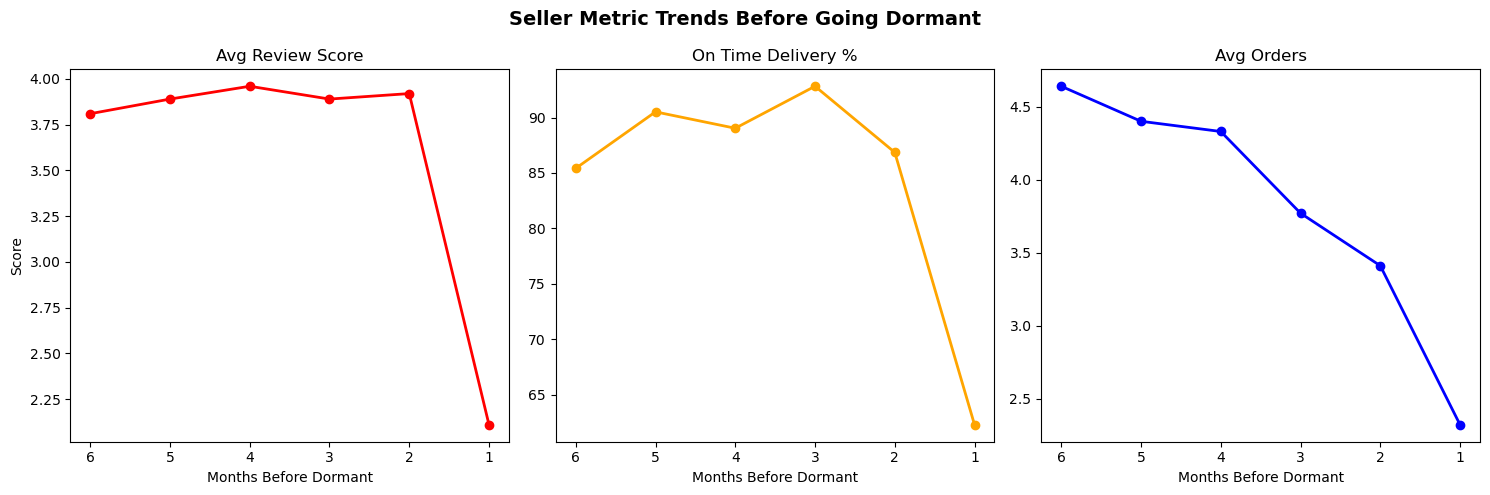

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Seller Metric Trends Before Going Dormant', fontsize=14, fontweight='bold')

x = dormant_trend['months_before_dormant']

# review score
axes[0].plot(x, dormant_trend['avg_review'], marker='o', color='red', linewidth=2)
axes[0].set_title('Avg Review Score')
axes[0].set_xlabel('Months Before Dormant')
axes[0].set_ylabel('Score')
axes[0].invert_xaxis()

# delivery rate
axes[1].plot(x, dormant_trend['avg_delivery'], marker='o', color='orange', linewidth=2)
axes[1].set_title('On Time Delivery %')
axes[1].set_xlabel('Months Before Dormant')
axes[1].invert_xaxis()

# order volume
axes[2].plot(x, dormant_trend['avg_orders'], marker='o', color='blue', linewidth=2)
axes[2].set_title('Avg Orders')
axes[2].set_xlabel('Months Before Dormant')
axes[2].invert_xaxis()

plt.tight_layout()

plt.show()

In [15]:
#Seller Specific Baseline Comparison for better result

seller_baseline = df.groupby('seller_id').agg(
    baseline_review = ('avg_review_score', 'mean'),
    baseline_delivery = ('on_time_delivery_pct', 'mean'),
    baseline_orders = ('total_orders', 'mean'),
    baseline_revenue = ('total_revenue', 'mean')
).round(2).reset_index()

seller_std = df.groupby('seller_id').agg(
    std_review = ('avg_review_score', 'std'),
    std_delivery = ('on_time_delivery_pct', 'std'),
    std_orders = ('total_orders', 'std')
).round(2).reset_index()


In [16]:
cols_to_drop = ['baseline_review', 'baseline_delivery', 'baseline_orders',
                'std_review', 'std_delivery', 'std_orders']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df = df.merge(seller_baseline, on='seller_id', how='left')
df = df.merge(seller_std, on='seller_id', how='left')

df['review_sharp_drop'] = (
    df['avg_review_score'] < df['baseline_review'] - df['std_review']
).astype(int)

df['delivery_sharp_drop'] = (
    df['on_time_delivery_pct'] < df['baseline_delivery'] - df['std_delivery']
).astype(int)

df['orders_sharp_drop'] = (
    df['total_orders'] < df['baseline_orders'] - df['std_orders']
).astype(int)

In [17]:
df['early_warning_flag'] = (
    (df['review_sharp_drop'] == 1) |
    (df['delivery_sharp_drop'] == 1) |
    (df['orders_sharp_drop'] == 1)
).astype(int)

df['early_warning_flag'].value_counts()

early_warning_flag
0    8179
1    3927
Name: count, dtype: int64

In [18]:
print('Unique sellers flagged :', df[df['early_warning_flag']==1]['seller_id'].nunique())

print("Review Score Triggers :", df['review_sharp_drop'].sum())
print("Order Volume Triggers :", df['orders_sharp_drop'].sum())
print("Delivery Status Triggers :", df['delivery_sharp_drop'].sum())

Unique sellers flagged : 1201
Review Score Triggers : 1959
Order Volume Triggers : 1344
Delivery Status Triggers : 1532


In [19]:
#Preparing Latest Records for Next Phase

df_latest = df.sort_values(['seller_id', 'sale_year', 'sale_month']).drop_duplicates(subset='seller_id', keep='last')
df_latest = df_latest.rename(columns = {'sale_year':'latest_year', 'sale_month':'latest_month'})

intervention_targets = df_latest[
    (df_latest['segment'].isin(['At-Risk', 'Dormant'])) &
    (df_latest['early_warning_flag'] == 1)
][['seller_id', 'seller_state', 'primary_category', 'health_score', 
   'segment', 'avg_review_score', 'on_time_delivery_pct', 
   'total_orders', 'review_sharp_drop', 'delivery_sharp_drop', 
   'orders_sharp_drop', 'baseline_review', 'baseline_delivery',
   'baseline_orders', 'seller_vintage', 'review_score_change',
   'order_volume_change', 'delivery_rate_change']].copy()

#print('Total Targets needing Intervention :', intervention_targets.shape[0])
df_latest.columns

Index(['seller_id', 'latest_year', 'latest_month', 'seller_state',
       'total_orders', 'total_revenue', 'on_time_delivery_pct',
       'cancellation_pct', 'avg_review_score', 'pct_low_reviews',
       'category_count', 'review_score_change', 'order_volume_change',
       'delivery_rate_change', 'first_active_month', 'last_active_month',
       'seller_vintage', 'primary_category', 'review_score_norm',
       'delivery_norm', 'order_volume_norm', 'cancellation_norm',
       'low_review_norm', 'health_score', 'segment', 'kmeans_segment',
       'baseline_review', 'baseline_delivery', 'baseline_orders',
       'baseline_revenue', 'std_review', 'std_delivery', 'std_orders',
       'review_sharp_drop', 'delivery_sharp_drop', 'orders_sharp_drop',
       'early_warning_flag'],
      dtype='object')

In [ ]:
#Final Export for Automated Co-Pilot

intervention_targets.to_csv('intervention_targets.csv', index=False)
print('Shape :', intervention_targets.shape)
print('Columns :', intervention_targets.columns.to_list())

Shape : (258, 18)
Columns : ['seller_id', 'seller_state', 'primary_category', 'health_score', 'segment', 'avg_review_score', 'on_time_delivery_pct', 'total_orders', 'review_sharp_drop', 'delivery_sharp_drop', 'orders_sharp_drop', 'baseline_review', 'baseline_delivery', 'baseline_orders', 'seller_vintage', 'review_score_change', 'order_volume_change', 'delivery_rate_change']


In [20]:
#Final Export for Dashboarding

final_columns = [
    # identifiers
    'seller_id', 'seller_state', 'primary_category',
    'seller_vintage', 'first_active_month', 'last_active_month',
    
    # time
    'latest_year', 'latest_month',
    
    # raw metrics
    'total_orders', 'total_revenue', 'avg_review_score',
    'on_time_delivery_pct', 'cancellation_pct', 
    'pct_low_reviews', 'category_count',
    
    # month over month deltas
    'review_score_change', 'order_volume_change', 'delivery_rate_change',
    
    # health scoring
    'health_score', 'segment',
    
    # early warning
    'review_sharp_drop', 'delivery_sharp_drop', 
    'orders_sharp_drop', 'early_warning_flag',
    
    # baselines
    'baseline_review', 'baseline_delivery', 'baseline_orders', 'baseline_revenue',

    #normalised values
    'order_volume_norm', 'review_score_norm', 'delivery_norm'
]

df_clean = df_latest[final_columns].copy()

df_clean = df_clean.rename(columns={
    'latest_year': 'sale_year',
    'latest_month': 'sale_month'
})

print(df_clean.shape)
df_clean.to_csv('seller_health_snapshot.csv', index=False)


(1246, 31)
